In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

print("Data shape:", X.shape)
print("Image shape:", digits.images[0].shape)

Data shape: (1797, 64)
Image shape: (8, 8)


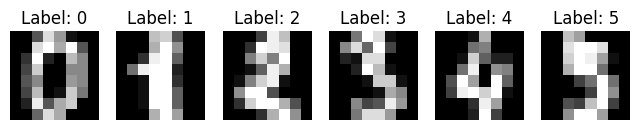

In [3]:
plt.figure(figsize=(8,3))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Label: {digits.target[i]}")
    plt.axis('off')

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)

print('U shape:', U.shape)
print('S shape:', S.shape)
print('Vt shape:', Vt.shape)

U shape: (1797, 64)
S shape: (64,)
Vt shape: (64, 64)


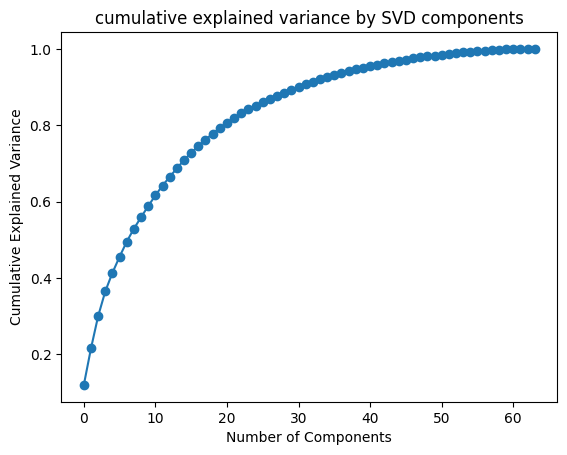

In [6]:
explained_variance = (S**2) / np.sum(S**2)

plt.figure()
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('cumulative explained variance by SVD components')
plt.show()

In [8]:
k=20
U_k = U[:, :k]
S_k=np.diag(S[:k])
VT_k=Vt[:k, :]

X_reduced = U_k @ S_k
print("X_reduced shape:", X_reduced.shape)

X_reduced shape: (1797, 20)


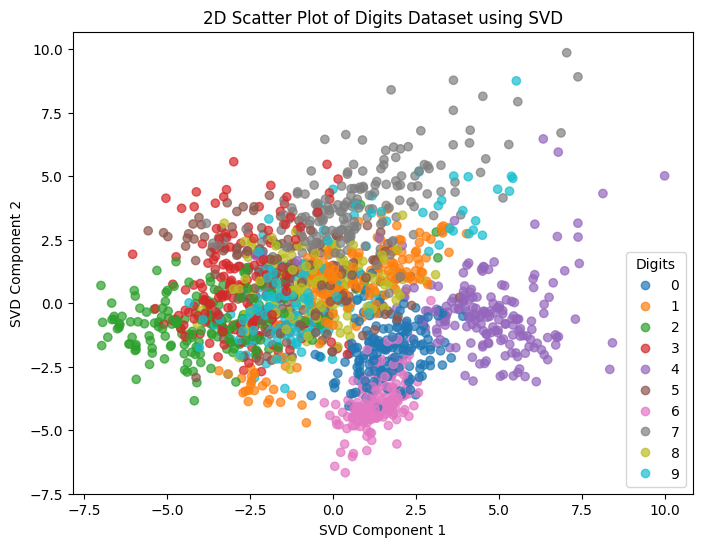

In [10]:
k_scatter = 2
U_k_scatter=U[:, :k_scatter]
S_k_scatter=np.diag(S[:k_scatter])

X_2D = U_k_scatter @ S_k_scatter
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_2D[:, 0], X_2D[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.title('2D Scatter Plot of Digits Dataset using SVD')
plt.legend(*scatter.legend_elements(), title="Digits")
plt.show()

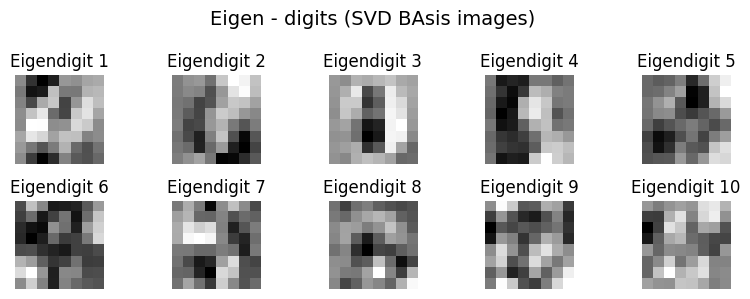

In [12]:
num_eigendigits=10
plt.figure(figsize=(8,3))
for i in range(num_eigendigits):
    plt.subplot(2,5,i+1)
    eigendigits=Vt[i].reshape(8,8)
    plt.imshow(eigendigits, cmap='gray')
    plt.title(f"Eigendigit {i+1}")
    plt.axis('off')
plt.suptitle('Eigen - digits (SVD BAsis images)', fontsize=14)
plt.tight_layout()
plt.show()

original image shape:  (8, 8)


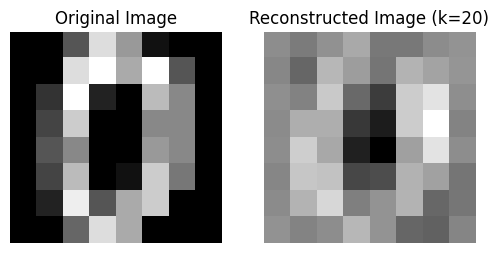

In [13]:
image_index=0
original_image=digits.images[image_index]
print("original image shape: ", original_image.shape)
reconstructed_image = (U_k[image_index] @ S_k) @ VT_k
reconstructed_image = reconstructed_image.reshape(8,8)
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title(f"Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title(f"Reconstructed Image (k={k})")
plt.axis('off')
plt.show()

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

clf_no_svd = LogisticRegression(max_iter=5000, multi_class='ovr')
clf_no_svd.fit(X_train, y_train)

y_pred_no_svd = clf_no_svd.predict(X_test)
acc_no_svd = accuracy_score(y_test, y_pred_no_svd)

acc_no_svd

c:\Users\ndhee\mlpractice\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


0.9629629629629629

In [24]:
svd=TruncatedSVD(n_components=20, random_state=42)

In [27]:
x_train_svd=svd.fit_transform(X_train)
x_test_svd=svd.transform(X_test)

clf_svd=LogisticRegression(max_iter=5000, multi_class='ovr')
clf_svd.fit(x_train_svd, y_train)
y_pred_svd=clf_svd.predict(x_test_svd)
accuracy_svd=accuracy_score(y_test, y_pred_svd)
accuracy_svd

c:\Users\ndhee\mlpractice\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


0.9296296296296296

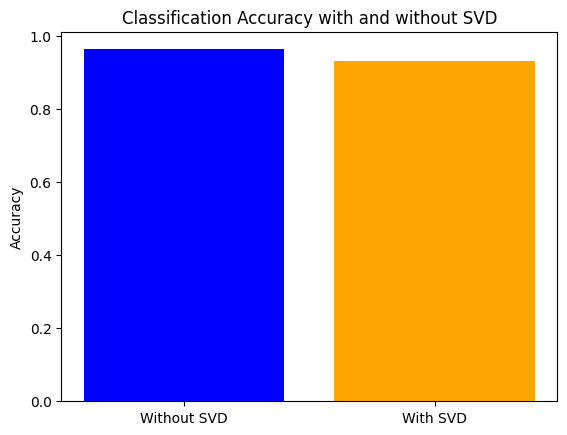

In [29]:
plt.figure()
plt.bar(['Without SVD', 'With SVD'], [acc_no_svd, accuracy_svd], color=['blue', 'orange'])
plt.ylabel('Accuracy')
plt.title('Classification Accuracy with and without SVD')
plt.show()

In [30]:
print(confusion_matrix(y_test, y_pred_svd))

[[52  0  1  0  0  0  0  0  0  0]
 [ 0 40  1  0  2  0  0  0  5  2]
 [ 0  2 45  0  0  0  0  0  0  0]
 [ 0  0  2 46  0  1  0  1  4  0]
 [ 0  0  0  0 60  0  0  0  0  0]
 [ 0  0  0  0  0 63  1  0  0  2]
 [ 0  0  0  0  1  0 52  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  1]
 [ 0  2  0  0  0  1  0  0 39  1]
 [ 0  2  0  3  0  1  0  0  2 51]]


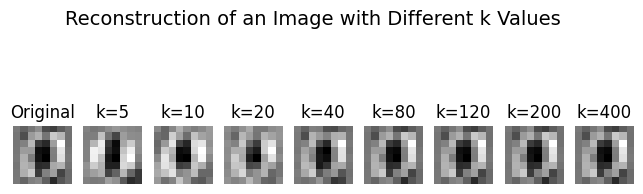

In [31]:
image_index=0
original=X_scaled[image_index].reshape(8,8)
k_values=[5,10,20,40,80,120,200,400]
plt.figure(figsize=(8,3))

plt.subplot(1, len(k_values)+1, 1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis('off')

for i, k in enumerate(k_values):
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    VT_k = Vt[:k, :]
    
    reconstructed = (U_k[image_index] @ S_k) @ VT_k
    reconstructed_image = reconstructed.reshape(8,8)
    
    plt.subplot(1, len(k_values)+1, i+2)
    plt.imshow(reconstructed_image, cmap='gray')
    plt.title(f"k={k}")
    plt.axis('off')
plt.suptitle('Reconstruction of an Image with Different k Values', fontsize=14)
plt.show()